# Universidad Nacional Autónoma de México
# Diplomado en Técnicas Estádisticas y Mineria de Datos

# Módulo II: Probabilidad y Modelos Estadísticos.
## Notebook 3: Estadística inferencial

## Nombre: José Manuel Gómez Vaca

---



### Introducción
En la práctica real del análisis cuantitativo, casi nunca conocemos los verdaderos parámetros de una población. Lo que poseemos es una **muestra aleatoria** $X_1, X_2, \dots, X_n$.

La **Estadística Inferencial** nos proporciona el marco riguroso para construir **estimadores**, que son funciones de la muestra diseñadas para aproximar parámetros desconocidos. En este módulo analizamos conceptualmente y formalmente los dos métodos de estimación clásica más importantes: el **Método de Momentos (MM)** y la **Estimación por Máxima Verosimilitud (EMV / MLE)** a través de tres escenarios con estructuras distintas.

# Parte 1: Estimadores

## 1. Definición Formal de Estimador

Sea $X_1, X_2, \dots, X_n$ una muestra aleatoria de variables independientes e idénticamente distribuidas (i.i.d.) con función de densidad o probabilidad $f(x; \theta)$, donde $\theta \in \Theta$ es el parámetro poblacional de interés.

* **Parámetro ($\theta$):** Una constante fija pero desconocida que caracteriza a la población (ej. $\mu, \sigma^2, \lambda, \theta$).
* **Estimador ($\hat{\Theta}_n$):** Una **función de la muestra aleatoria**, es decir, $\hat{\Theta}_n = g(X_1, X_2, \dots, X_n)$. Como depende de variables aleatorias, **el estimador es en sí mismo una variable aleatoria** y posee su propia distribución de probabilidad (distribución muestral).
* **Estimación ($\hat{\theta}$):** El **valor numérico observado** que toma el estimador al evaluar una realización concreta de la muestra $\hat{\theta} = g(x_1, x_2, \dots, x_n)$.

> **Intuición:** Un estimador es la *fórmula o regla matemática* (variable aleatoria), mientras que la estimación es el *resultado numérico concreto* obtenido con un conjunto de datos recopilados.

## 2. Definición Formal de los Métodos de Estimación

### 2.1 Método de Momentos (MM)
Se basa en el **Principio de Analogía**. Igualamos los momentos poblacionales teóricos $\mu_k = \mathbb{E}[X^k]$ con los momentos muestrales empíricos $m_k = \frac{1}{n} \sum_{i=1}^n X_i^k$. Para estimar $k$ parámetros, resolvemos el sistema:
$$\mathbb{E}[X^r] = \frac{1}{n} \sum_{i=1}^n X_i^r, \quad r = 1, 2, \dots, k$$

### 2.2 Máxima Verosimilitud (EMV / MLE)
Busca el valor del parámetro $\theta$ que maximiza la probabilidad conjunta de haber observado exactamente la muestra $x_1, \dots, x_n$. Se define la función de verosimilitud $L(\theta; \mathbf{x}) = \prod_{i=1}^n f(x_i; \theta)$ y su versión logarítmica $\ell(\theta; \mathbf{x}) = \ln L(\theta; \mathbf{x}) = \sum_{i=1}^n \ln f(x_i; \theta)$. El estimador maximiza dicha función:
$$\hat{\theta}_{MLE} = \arg\max_{\theta \in \Theta} \ell(\theta; \mathbf{x})$$

--- 
## 3. Ejemplo 1: Distribución Poisson (Parámetro Único Discreto)

### Planteamiento:
Sea $X_1, \dots, X_n \sim \text{Poisson}(\lambda)$ i.i.d. Representa el número de eventos independientes ocurridos por unidad de tiempo.

### Derivación Matemática:
* **Método de Momentos:**
  $$\mathbb{E}[X] = \lambda \implies m_1 = \bar{X} \implies \hat{\lambda}_{MM} = \bar{X}$$
* **Máxima Verosimilitud:**
  $$L(\lambda) = \prod_{i=1}^n \frac{e^{-\lambda} \lambda^{x_i}}{x_i!} = e^{-n\lambda} \lambda^{\sum x_i} \prod_{i=1}^n \frac{1}{x_i!}$$
  $$\ell(\lambda) = -n\lambda + \left(\sum_{i=1}^n x_i\right) \ln\lambda - \sum_{i=1}^n \ln(x_i!)$$
  $$\frac{d\ell}{d\lambda} = -n + \frac{\sum x_i}{\lambda} = 0 \implies \hat{\lambda}_{MLE} = \bar{X}$$

In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

np.random.seed(42)

# Ejemplo 1: Poisson
lambda_real = 4.5
n_poisson = 50
sample_poisson = stats.poisson.rvs(mu=lambda_real, size=n_poisson)

# Estimadores
lambda_mm = np.mean(sample_poisson)
lambda_mle = np.mean(sample_poisson)

print('--- EJEMPLO 1: POISSON ---')
print(f'Parámetro Real (λ): {lambda_real}')
print(f'Estimador MM (λ):   {lambda_mm:.4f}')
print(f'Estimador MLE (λ):  {lambda_mle:.4f}')

--- EJEMPLO 1: POISSON ---
Parámetro Real (λ): 4.5
Estimador MM (λ):   4.6200
Estimador MLE (λ):  4.6200


--- 
## 4. Ejemplo 2: Distribución Normal (Multiparámetro Continuo)

### Planteamiento:
Sea $X_1, \dots, X_n \sim \mathcal{N}(\mu, \sigma^2)$ i.i.d. Deseamos estimar la media $\mu$ y la varianza $\sigma^2$.

### Derivación Matemática:
* **Método de Momentos:**
  1. Primer momento: $\mathbb{E}[X] = \mu = m_1 \implies \hat{\mu}_{MM} = \bar{X}$
  2. Segundo momento: $\mathbb{E}[X^2] = \sigma^2 + \mu^2 = m_2 = \frac{1}{n}\sum X_i^2$
  3. Despeje varianza: $\hat{\sigma}^2_{MM} = m_2 - \bar{X}^2 = \frac{1}{n}\sum_{i=1}^n (X_i - \bar{X})^2$

* **Máxima Verosimilitud:**
  $$\ell(\mu, \sigma^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln(\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2$$
  Derivando respecto a $\mu$ y $\sigma^2$ e igualando a cero:
  $$\hat{\mu}_{MLE} = \bar{X}, \quad \hat{\sigma}^2_{MLE} = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{X})^2$$

> **Nota sobre la Varianza:** Nótese que tanto el MM como el MLE estiman la varianza dividiendo entre $n$, a diferencia de la varianza muestral insesgada $S^2$ que divide entre $n-1$.

In [3]:
# Ejemplo 2: Normal
mu_real, sigma2_real = 10.0, 4.0
n_normal = 30
sample_normal = stats.norm.rvs(loc=mu_real, scale=np.sqrt(sigma2_real), size=n_normal)

# Estimadores MM y MLE (Coinciden en las fórmulas plug-in directas)
mu_mm = np.mean(sample_normal)
sigma2_mm = np.var(sample_normal, ddof=0)  # ddof=0 divide entre n

mu_mle = mu_mm
sigma2_mle = sigma2_mm

# Comparación con la varianza muestral insesgada S^
s2_insesgada = np.var(sample_normal, ddof=1)  # ddof=1 divide entre n-1

print('--- EJEMPLO 2: NORMAL ---')
print(f'Parámetros Reales: μ = {mu_real}, σ² = {sigma2_real}')
print(f'Estimación de μ (MM / MLE): {mu_mle:.4f}')
print(f'Estimación de σ² (MM / MLE, /n): {sigma2_mle:.4f}')
print(f'Estimación de σ² Insesgada (S², /n-1): {s2_insesgada:.4f}')

--- EJEMPLO 2: NORMAL ---
Parámetros Reales: μ = 10.0, σ² = 4.0
Estimación de μ (MM / MLE): 9.9654
Estimación de σ² (MM / MLE, /n): 4.4393
Estimación de σ² Insesgada (S², /n-1): 4.5923


--- 
## 5. Ejemplo 3: Distribución Uniforme Continuas en $(0, \theta)$ (Soporte Dependiente del Parámetro)

### Planteamiento:
Sea $X_1, \dots, X_n \sim \text{Unif}(0, \theta)$ i.i.d. Este caso es emblemático porque ilustra una situación donde **el MM y el EMV entregan estimadores con estructuras completamente distintas**.

### Derivación Matemática:
* **Método de Momentos:**
  $$\mathbb{E}[X] = \frac{\theta}{2} = \bar{X} \implies \hat{\theta}_{MM} = 2\bar{X}$$

* **Máxima Verosimilitud:**
  La densidad es $f(x; \theta) = \frac{1}{\theta} \mathbb{I}_{(0 \le x \le \theta)}$. La verosimilitud es:
  $$L(\theta) = \frac{1}{\theta^n} \quad \text{para } \theta \ge \max(x_1, \dots, x_n)$$
  Como $\frac{1}{\theta^n}$ es una función decreciente de $\theta$, para maximizar $L(\theta)$ debemos elegir el valor más pequeño posible de $\theta$ que sea compatible con los datos observados:
  $$\hat{\theta}_{MLE} = X_{(n)} = \max(X_1, X_2, \dots, X_n)$$

In [4]:
# Ejemplo 3: Uniforme (0, theta)
theta_real = 15.0
n_unif = 25
sample_unif = stats.uniform.rvs(loc=0, scale=theta_real, size=n_unif)

# Estimadores
theta_mm = 2 * np.mean(sample_unif)
theta_mle = np.max(sample_unif)

print('--- EJEMPLO 3: UNIFORME (0, θ) ---')
print(f'Parámetro Real (θ): {theta_real}')
print(f'Estimador MM (2*X_bar): {theta_mm:.4f}')
print(f'Estimador MLE (X_(n)):  {theta_mle:.4f}')

--- EJEMPLO 3: UNIFORME (0, θ) ---
Parámetro Real (θ): 15.0
Estimador MM (2*X_bar): 13.2176
Estimador MLE (X_(n)):  14.3230


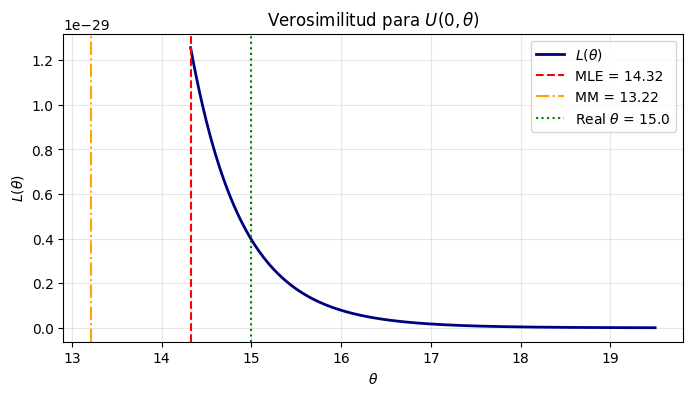

In [9]:
# Valores posibles del parámetro θ
theta_grid = np.linspace(np.max(sample_unif), theta_real*1.3, 300)

# Calculamos la verosimilitud L(θ)=1/θ^n para θ ≥ X(n)
likelihood = [1/(theta**n_unif) for theta in theta_grid]

plt.figure(figsize=(8,4))

# Curva de verosimilitud
plt.plot(theta_grid, likelihood, color="navy", lw=2, 
         label=r"$L(\theta)$")

# Estimadores
plt.axvline(theta_mle, color="red", linestyle="--",
            label=rf"MLE = {theta_mle:.2f}")

plt.axvline(theta_mm, color="orange", linestyle="-.",
            label=rf"MM = {theta_mm:.2f}")

plt.axvline(theta_real, color="green", linestyle=":",
            label=rf"Real $\theta$ = {theta_real}")

plt.title(r"Verosimilitud para $U(0,\theta)$")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$L(\theta)$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 6. Interpretación de Resultados y Comparación General

Al comparar los estimadores obtenidos mediante máxima verosimilitud (MLE) y método de momentos (MM), se observa que su comportamiento depende de la estructura de cada distribución.

* **Poisson:** Ambos métodos conducen al mismo estimador, ya que el parámetro $\lambda$ queda estimado directamente por la media muestral $\bar{X}$.

* **Normal:** Para la media, ambos enfoques producen el mismo resultado mediante $\bar{X}$. En el caso de la varianza, el estimador obtenido por máxima verosimilitud utiliza el divisor $n$, mientras que el estimador clásico de la varianza utiliza $n-1$. Esta diferencia es pequeña para tamaños de muestra grandes.

* **Uniforme $(0,\theta)$:** En esta distribución se observa una diferencia importante entre ambos métodos. El estimador por momentos, $2\bar{X}$, no siempre considera la restricción del parámetro definida por los datos observados. En cambio, el estimador de máxima verosimilitud, $\hat{\theta}=X_{(n)}$, utiliza el valor máximo de la muestra y garantiza que la estimación sea compatible con el rango posible de la distribución.

En general, los resultados muestran que no existe un único método de estimación que sea siempre superior. El desempeño de cada estimador depende de las características del modelo y de las propiedades que se quieran analizar, como insesgadez, consistencia y eficiencia.

# Parte 2: Propiedades técnicas de los estimadores

---

### Introducción
En la parte 1 vimos que para un mismo parámetro poblacional $\theta$ podemos construir distintos estimadores (por ejemplo, usando el Método de Momentos o Máxima Verosimilitud). Esto plantea una pregunta natural: **¿cuál estimador deberíamos elegir?**

Para decidirlo, la Estadística Inferencial evalúa las **propiedades teóricas** de los estimadores. En esta sección estudiaremos tres pilares fundamentales: **Insesgadez**, **Consistencia** y **Eficiencia**.

--- 
## 1. Insesgadez (Unbiasedness)

### 1.1 Definición Formal
Un estimador $\hat{\Theta}_n$ es **insesgado** si y solo sí, para el parámetro $\theta$ si el valor esperado de su distribución muestral es igual al verdadero parámetro poblacional para cualquier tamaño de muestra $n$:

$$\mathbb{E}[\hat{\Theta}_n] = \theta$$

El **Sesgo** de un estimador se define como:
$$B(\hat{\Theta}_n) = \mathbb{E}[\hat{\Theta}_n] - \theta$$

* Si $B(\hat{\Theta}_n) = 0$, el estimador es insesgado.
* Si $B(\hat{\Theta}_n) \to 0$ cuando $n \to \infty$, se dice que el estimador es **asintóticamente insesgado**.

**Intuición:** Insesgadez no significa que una sola estimación será exacta, sino que, si tomáramos infinitas muestras del mismo tamaño y promediáramos los resultados de nuestro estimador, le daríamos al *blanco* exacto del parámetro real.

### 1.2 Demostración Formal: El Caso de la Varianza
Supongamos una muestra $X_1, \dots, X_n$ i.i.d. con $\mathbb{E}[X_i] = \mu$ y $\text{Var}(X_i) = \sigma^2$.

1. **Estimador de Máxima Verosimilitud / Momentos:** $\hat{\sigma}^2_{MLE} = \frac{1}{n} \sum_{i=1}^n (X_i - \bar{X})^2$
   Calculando su esperanza:
   $$\mathbb{E}[\hat{\sigma}^2_{MLE}] = \frac{n-1}{n} \sigma^2$$
   Su sesgo es $B(\hat{\sigma}^2_{MLE}) = -\frac{\sigma^2}{n}$. Es decir, **subestima sistemáticamente** la varianza en muestras pequeñas.

2. **Varianza Muestral Corregida:** $S^2 = \frac{1}{n-1} \sum_{i=1}^n (X_i - \bar{X})^2$
   $$\mathbb{E}[S^2] = \mathbb{E}\left[\frac{n}{n-1} \hat{\sigma}^2_{MLE}\right] = \frac{n}{n-1} \left(\frac{n-1}{n} \sigma^2\right) = \sigma^2$$
   El factor $\frac{1}{n-1}$ (corrección de Bessel) elimina el sesgo exacto para cualquier $n$.

In [10]:
# Simulamos el sesgo de la varianza en muestras pequeñas usando simulación Monte Carlo
np.random.seed(42)
sigma2_real = 9.0  # Varianza poblacional conocida (std = 3)
mu_real = 50.0
n_pequeno = 5     # Muestra deliberadamente pequeña para evidenciar el sesgo
num_simulaciones = 10000

# Generamos 10,000 muestras de tamaño n=5
muestras = stats.norm.rvs(loc=mu_real, scale=np.sqrt(sigma2_real), size=(num_simulaciones, n_pequeno))

# Calculamos ambas varianzas para cada muestra
var_mle_sim = np.var(muestras, axis=1, ddof=0)  # Dividido por n
var_s2_sim = np.var(muestras, axis=1, ddof=1)   # Dividido por n-1

print('='*50)
print('  SIMULACIÓN DE INSESGADEZ EN LA VARIANZA (n = 5)')
print('='*50)
print(f'Varianza Real Poblacional (σ²):     {sigma2_real:.4f}')
print(f'Promedio de S² (dividido n-1):      {np.mean(var_s2_sim):.4f} -> ¡INSESGADO!')
print(f'Promedio de σ²_MLE (dividido n):    {np.mean(var_mle_sim):.4f} -> (Sesgado)')
print(f'Esperanza Teórica de σ²_MLE ((n-1)/n * σ²): {(n_pequeno-1)/n_pequeno * sigma2_real:.4f}')
print('='*50)

  SIMULACIÓN DE INSESGADEZ EN LA VARIANZA (n = 5)
Varianza Real Poblacional (σ²):     9.0000
Promedio de S² (dividido n-1):      8.9823 -> ¡INSESGADO!
Promedio de σ²_MLE (dividido n):    7.1858 -> (Sesgado)
Esperanza Teórica de σ²_MLE ((n-1)/n * σ²): 7.2000


--- 
## 2. Consistencia (Consistency)

### 2.1 Definición Formal
La insesgadez es una propiedad de muestras finitas, pero la **consistencia** describe el comportamiento asintótico. Un estimador $\hat{\Theta}_n$ es **consistente** si converge en probabilidad al verdadero parámetro $\theta$ conforme el tamaño de la muestra tiende a infinito:

$$\lim_{n \to \infty} P\left( |\hat{\Theta}_n - \theta| > \epsilon \right) = 0, \quad \forall \epsilon > 0$$

O equivalentemente: $\hat{\Theta}_n \xrightarrow{P} \theta$.

### Condición Suficiente para Consistencia:
Si un estimador cumple que:
1. $\lim_{n \to \infty} \mathbb{E}[\hat{\Theta}_n] = \theta$ (Asintóticamente insesgado)
2. $\lim_{n \to \infty} \text{Var}(\hat{\Theta}_n) = 0$

Entonces, por la **Desigualdad de Chebyshev**, el estimador es consistente.

**Intuición:** Conforme recolectamos más datos ($n \to \infty$), la incertidumbre del estimador se colapsa a cero y la estimación se pega al valor real.

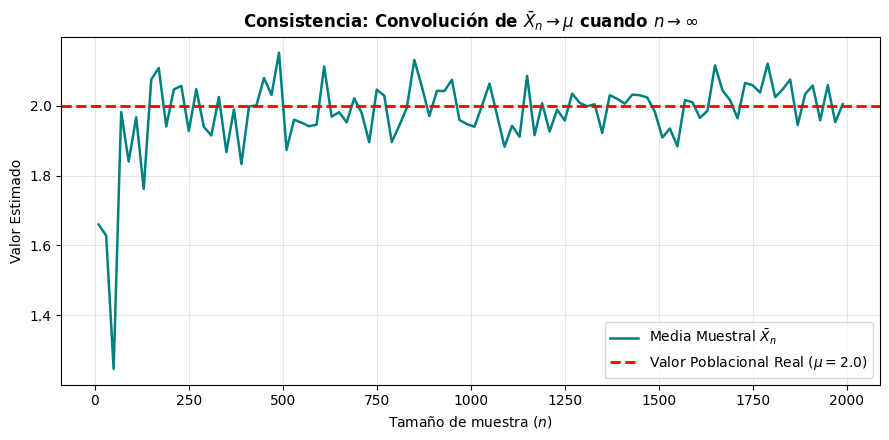

In [11]:
# Visualización de la Consistencia: Comportamiento de la Media Muestral al crecer n
tamaños_n = np.arange(10, 2000, 20)
estimaciones_media = []

# Fijamos una población Exponencial(lambda = 0.5) -> Media poblacional mu = 2.0
lambda_param = 0.5
mu_poblacional = 1.0 / lambda_param

for n in tamaños_n:
    muestra_exp = stats.expon.rvs(scale=mu_poblacional, size=n)
    estimaciones_media.append(np.mean(muestra_exp))

plt.figure(figsize=(9, 4.5))
plt.plot(tamaños_n, estimaciones_media, color='teal', lw=1.8, label=r'Media Muestral $\bar{X}_n$')
plt.axhline(mu_poblacional, color='red', linestyle='--', lw=2, label=r'Valor Poblacional Real ($\mu = 2.0$)')
plt.title(r'Consistencia: Convolución de $\bar{X}_n \to \mu$ cuando $n \to \infty$', fontweight='bold')
plt.xlabel('Tamaño de muestra ($n$)')
plt.ylabel('Valor Estimado')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

--- 
## 3. Eficiencia y Cota de Cramér-Rao

### 3.1 Definición y Varianza Mínima
Entre dos estimadores insesgados $\hat{\Theta}_1$ y $\hat{\Theta}_2$, decimos que **$\hat{\Theta}_1$ es más eficiente que $\hat{\Theta}_2$** si su varianza es menor:

$$\text{Var}(\hat{\Theta}_1) < \text{Var}(\hat{\Theta}_2)$$

### 3.2 Cota Inferior de Cramér-Rao (CICR)
Existe un límite físico-matemático a la precisión de cualquier estimador insesgado. Bajo condiciones de regularidad, la varianza de cualquier estimador insesgado $\hat{\Theta}_n$ está acotada por:

$$\text{Var}(\hat{\Theta}_n) \ge \frac{1}{I_n(\theta)} = \frac{1}{n I_1(\theta)}$$

Donde $I_1(\theta)$ es la **Información de Fisher** contenida en una sola observación:

$$I_1(\theta) = \mathbb{E}\left[ \left( \frac{\partial \ln f(X; \theta)}{\partial \theta} \right)^2 \right] = -\mathbb{E}\left[ \frac{\partial^2 \ln f(X; \theta)}{\partial \theta^2} \right]$$

* Si $\text{Var}(\hat{\Theta}_n) = \frac{1}{n I_1(\theta)}$, el estimador alcanza la cota y se llama **Estimador Insesgado de Varianza Mínima (UMVU / EIVM)**.

In [12]:
# Comprobación de Eficiencia: Media Muestral vs. Mediana Muestral en una Normal
# Ambos son estimadores insesgados de la media mu, ¿cuál tiene menor varianza?

n_eficiencia = 30
n_experimentos = 8000
mu_norm, sigma_norm = 100.0, 15.0

# Generamos 8,000 experimentos de tamaño n=30
muestras_norm = stats.norm.rvs(loc=mu_norm, scale=sigma_norm, size=(n_experimentos, n_eficiencia))

medias_muestrales = np.mean(muestras_norm, axis=1)
medianas_muestrales = np.median(muestras_norm, axis=1)

# Varianza observada
var_media = np.var(medias_muestrales, ddof=1)
var_mediana = np.var(medianas_muestrales, ddof=1)

# Cota Teórica de Cramér-Rao para la media de una Normal: sigma^2 / n
cota_cramer_rao = (sigma_norm**2) / n_eficiencia

print('='*55)
print('  EFICIENCIA: MEDIA MUESTRAL VS. MEDIANA MUESTRAL')
print('='*55)
print(f'Cota Inferior de Cramér-Rao (σ²/n):  {cota_cramer_rao:.4f}')
print(f'Varianza Observada de la Media:       {var_media:.4f} -> ¡Alcanza la Cota!')
print(f'Varianza Observada de la Mediana:     {var_mediana:.4f} -> (Menos eficiente)')
print(f'Eficiencia Relativa (Var_Media / Var_Mediana): {var_media / var_mediana:.4f}')
print('='*55)

  EFICIENCIA: MEDIA MUESTRAL VS. MEDIANA MUESTRAL
Cota Inferior de Cramér-Rao (σ²/n):  7.5000
Varianza Observada de la Media:       7.4704 -> ¡Alcanza la Cota!
Varianza Observada de la Mediana:     11.1257 -> (Menos eficiente)
Eficiencia Relativa (Var_Media / Var_Mediana): 0.6715


## 4. Resumen e Interpretación Cuantitativa

| Propiedad | Criterio Matemático | Interpretación |
|---|---|---|
| **Insesgadez** | $\mathbb{E}[\hat{\Theta}]=\theta$ | El valor esperado del estimador coincide con el verdadero parámetro, por lo que no presenta un sesgo sistemático en sus estimaciones. |
| **Consistencia** | $\hat{\Theta}_n \xrightarrow{P}\theta$ | Al incrementar el tamaño de muestra, el estimador se aproxima al valor real del parámetro con mayor probabilidad. |
| **Eficiencia** | $\text{Var}(\hat{\Theta}) \geq \frac{1}{nI_1(\theta)}$ | Permite comparar estimadores mediante su variabilidad. Un estimador más eficiente presenta menor dispersión alrededor del parámetro verdadero. |

### Conclusión

Las propiedades anteriores permiten evaluar la calidad de un estimador más allá de obtener un valor puntual. Un estimador puede ser insesgado, pero presentar una alta variabilidad; por ello también es importante analizar su consistencia y eficiencia.

En el caso de una población Normal con varianza conocida, la media muestral $\bar{X}$ es un estimador insesgado y consistente para $\mu$. Además, alcanza la Cota de Cramér-Rao, por lo que representa un estimador eficiente dentro de esta familia de modelos.

# Parte 3: Intervalos de Confianza (IC)

---

## 1. Fundamentos Matemáticos de la Estimación por Intervalos

### 1.1 Definición Formal
Sea $X_1, X_2, \dots, X_n$ una muestra aleatoria independiente e idénticamente distribuida (i.i.d.) proveniente de una función de densidad $f(x; \theta)$, donde $\theta \in \Theta \subseteq \mathbb{R}$ es el parámetro poblacional de interés.

Un **Intervalo de Confianza** del $(1-\alpha)\times 100\%$ para $\theta$ es un par de estadísticas muestrales $L_I(\mathbf{X})$ y $L_S(\mathbf{X})$ tales que:

$$P\Big( L_I(\mathbf{X}) \le \theta \le L_S(\mathbf{X}) \Big) = 1 - \alpha, \quad \forall \theta \in \Theta$$

Donde:
* $1 - \alpha$ es el **nivel de confianza** (habitualmente $0.90, 0.95, 0.99$).
* $\alpha$ es el **nivel de significancia** (probabilidad teórica de error de cobertura).
* $[L_I(\mathbf{X}), L_S(\mathbf{X})]$ define el intervalo aleatorio.

 **Interpretación Frecuentista Rigurosa:**
 El parámetro $\theta$ es una constante desconocida **fija**, no una variable aleatoria. Por lo tanto, la afirmación $P(2.5 \le \mu \le 5.8) = 0.95$ es formalmente incorrecta en el enfoque frecuentista. La probabilidad $1-\alpha$ recae sobre el **método de construcción del intervalo aleatorio** $[L_I, L_S]$. Si repetimos el muestreo un número infinito de veces, el $(1-\alpha)\%$ de los intervalos calculados contendrá al parámetro real $\theta$.

--- 
## 2. Intervalos de Confianza para la Media Poblacional ($\mu$)

### 2.1 Varianza Conocida (Pivote Normal $Z$)
Si $X_i \sim \mathcal{N}(\mu, \sigma^2)$ con $\sigma^2$ conocida, o si $n$ es suficientemente grande ($n \ge 30$) para aplicar el **Teorema del Límite Central (TLC)**:

$$Q(\mathbf{X}, \mu) = \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} \sim \mathcal{N}(0, 1)$$

Despejando $\mu$:
$$\text{IC}_{1-\alpha}(\mu) = \left[ \bar{X} - Z_{\alpha/2} \frac{\sigma}{\sqrt{n}}, \quad \bar{X} + Z_{\alpha/2} \frac{\sigma}{\sqrt{n}} \right]$$

### 2.2 Varianza Desconocida (Pivote $t$-Student)
Si $\sigma^2$ es desconocida y $n < 30$, reemplazamos $\sigma$ por la desviación muestral insesgada $S = \sqrt{\frac{1}{n-1}\sum_{i=1}^n (X_i - \bar{X})^2}$. Por el **Teorema de Gosset**:

$$T = \frac{\bar{X} - \mu}{S / \sqrt{n}} \sim t_{n-1}$$

$$\text{IC}_{1-\alpha}(\mu) = \left[ \bar{X} - t_{\alpha/2, n-1} \frac{S}{\sqrt{n}}, \quad \bar{X} + t_{\alpha/2, n-1} \frac{S}{\sqrt{n}} \right]$$

In [3]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

# Fijar semilla de aleatoriedad
np.random.seed(2026)

# CASO PRÁCTICO: Análisis de Rendimiento Financiero diario de un Portafolio Quant (en %)
n_obs = 18
rendimientos_reales = stats.norm.rvs(loc=1.25, scale=0.85, size=n_obs)

# Cálculo de estadísticas descriptivas esenciales
media_m = np.mean(rendimientos_reales)
std_m = np.std(rendimientos_reales, ddof=1)  # Dividido entre n-1
se_m = std_m / np.sqrt(n_obs)

# Niveles de confianza a evaluar
confianzas = [0.90, 0.95, 0.99]
resultados_media = []

for conf in confianzas:
    alpha = 1 - conf
    t_crit = stats.t.ppf(1 - alpha/2, df=n_obs-1)
    margen_e = t_crit * se_m
    lim_inf = media_m - margen_e
    lim_sup = media_m + margen_e
    
    resultados_media.append({
        'Confianza': f'{int(conf*100)}%',
        'Media Muestral': round(media_m, 4),
        'Error Estándar': round(se_m, 4),
        'Valor Crítico t': round(t_crit, 4),
        'Margen de Error (±)': round(margen_e, 4),
        'IC Inferior': round(lim_inf, 4),
        'IC Superior': round(lim_sup, 4),
        'Ancho Intervalo': round(lim_sup - lim_inf, 4)
    })

df_res_media = pd.DataFrame(resultados_media)
print('='*120)
print('   INTERVALOS DE CONFIANZA PARA LA MEDIA μ (VARIOS NIVELES DE CONFIANZA)')
print('='*120)
print(df_res_media.to_string(index=False))
print('='*120)

   INTERVALOS DE CONFIANZA PARA LA MEDIA μ (VARIOS NIVELES DE CONFIANZA)
Confianza  Media Muestral  Error Estándar  Valor Crítico t  Margen de Error (±)  IC Inferior  IC Superior  Ancho Intervalo
      90%          1.0819          0.1876           1.7396               0.3263       0.7556       1.4082           0.6526
      95%          1.0819          0.1876           2.1098               0.3957       0.6862       1.4776           0.7914
      99%          1.0819          0.1876           2.8982               0.5436       0.5383       1.6255           1.0872


### 2.3 Tamaño Muestral Óptimo para Determinar la Media
En la práctica analítica, un requerimiento común es fijar un **margen de error máximo tolerable ($E$)**. Despejando $n$ de la fórmula del error estándar en el caso Normal:

$$E = Z_{\alpha/2} \frac{\sigma}{\sqrt{n}} \implies n = \left( \frac{Z_{\alpha/2} \cdot \sigma}{E} \right)^2$$

Si $\sigma$ es desconocida, se realiza un **estudio piloto** o se toma la desviación estándar histórica como aproximación.

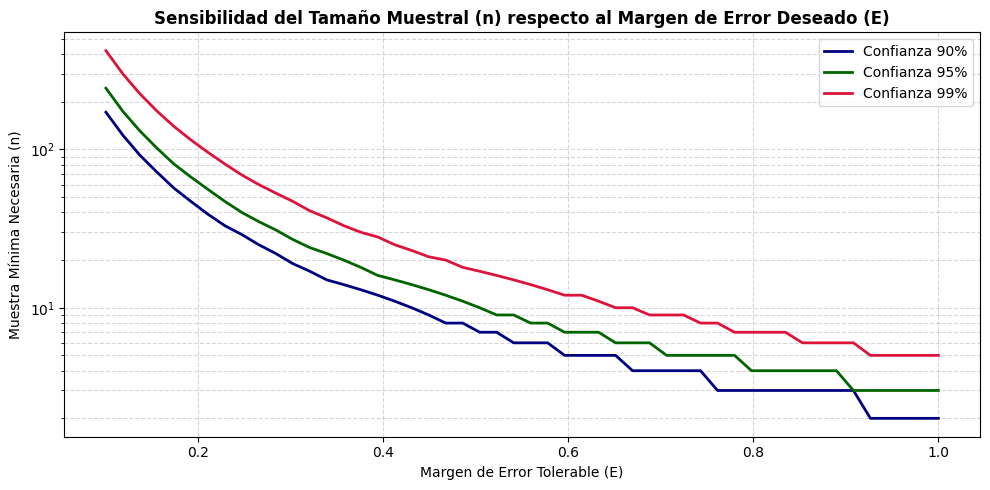

In [4]:
# Visualización de la relación entre Tamaño Muestral (n), Margen de Error (E) y Nivel de Confianza
errores_tolerables = np.linspace(0.1, 1.0, 50)
sigma_piloto = std_m

plt.figure(figsize=(10, 5))

for conf, color in zip([0.90, 0.95, 0.99], ['navy', 'darkgreen', 'crimson']):
    alpha = 1 - conf
    z_c = stats.norm.ppf(1 - alpha/2)
    tam_muestrales = np.ceil((z_c * sigma_piloto / errores_tolerables)**2)
    plt.plot(errores_tolerables, tam_muestrales, label=f'Confianza {int(conf*100)}%', color=color, lw=2)

plt.title('Sensibilidad del Tamaño Muestral (n) respecto al Margen de Error Deseado (E)', fontweight='bold')
plt.xlabel('Margen de Error Tolerable (E)')
plt.ylabel('Muestra Mínima Necesaria (n)')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

--- 
## 3. Intervalos de Confianza para la proporción ($p$)

Cuando analizamos variables cualitativas dicotómicas, la variable de interés sigue una distribución Binomial $X \sim \text{Binomial}(n, p)$.

### 3.1 Intervalo Asintótico de Wald
Basado en el Teorema del Límite Central, aproxima la Binomial a una Normal cuando $n\hat{p} \ge 10$ y $n(1-\hat{p}) \ge 10$:

$$\text{IC}_{Wald}(p) = \left[ \hat{p} - Z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}, \quad \hat{p} + Z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}} \right]$$

### 3.2 Intervalo de Wilson Score
Elimina la distorsión del método de Wald cuando $p$ está cerca de $0$ o $1$, o cuando $n$ es chico:

$$\text{IC}_{Wilson}(p) = \frac{\hat{p} + \frac{Z^2}{2n} \pm Z \sqrt{\frac{\hat{p}(1-\hat{p})}{n} + \frac{Z^2}{4n^2}}}{1 + \frac{Z^2}{n}}$$

### 3.3 Intervalo Exacto de Clopper-Pearson
Basado en la distribución Beta y Binomial acumulada. Garantiza una cobertura **no menor** al $(1-\alpha)\%$.

In [11]:
from statsmodels.stats.proportion import proportion_confint

# CASO PRÁCTICO: Tasa de defecto en un lote de producción
k_defectos = 4
n_inspeccionados = 80
p_hat_def = k_defectos / n_inspeccionados
conf_prop = 0.95

# Cálculo con 3 métodos en Python
ic_wald = proportion_confint(k_defectos, n_inspeccionados, alpha=1-conf_prop, method='normal')
ic_wilson = proportion_confint(k_defectos, n_inspeccionados, alpha=1-conf_prop, method='wilson')
ic_exacto = proportion_confint(k_defectos, n_inspeccionados, alpha=1-conf_prop, method='beta')

df_props = pd.DataFrame({
    'Método': ['Wald (Clásico)', 'Wilson Score (Recomendado)', 'Clopper-Pearson (Exacto)'],
    'Límite Inferior (p)': [round(ic_wald[0], 4), round(ic_wilson[0], 4), round(ic_exacto[0], 4)],
    'Límite Superior (p)': [round(ic_wald[1], 4), round(ic_wilson[1], 4), round(ic_exacto[1], 4)],
    'Ancho del IC': [round(ic_wald[1]-ic_wald[0], 4), round(ic_wilson[1]-ic_wilson[0], 4), round(ic_exacto[1]-ic_exacto[0], 4)]
})

print('='*82)
print(f'   COMPARACIÓN DE INTERVALOS PARA UNA PROPORCIÓN (x={k_defectos}, n={n_inspeccionados}, p̂={p_hat_def:.4f})')
print('='*82)
print(df_props.to_string(index=False))
print('='*82)

   COMPARACIÓN DE INTERVALOS PARA UNA PROPORCIÓN (x=4, n=80, p̂=0.0500)
                    Método  Límite Inferior (p)  Límite Superior (p)  Ancho del IC
            Wald (Clásico)               0.0022               0.0978        0.0955
Wilson Score (Recomendado)               0.0196               0.1216        0.1020
  Clopper-Pearson (Exacto)               0.0138               0.1231        0.1093


--- 
## 4. Intervalo para la Diferencia de Medias ($\mu_1 - \mu_2$)

### 4.1 Varianzas Iguales Asumidas (Pooled $t$)
Si $\sigma_1^2 = \sigma_2^2 = \sigma^2$, estimamos la varianza amalgamada (*pooled variance*):

$$S_p^2 = \frac{(n_1 - 1)S_1^2 + (n_2 - 1)S_2^2}{n_1 + n_2 - 2}$$

$$\text{IC}_{1-\alpha}(\mu_1 - \mu_2) = (\bar{X}_1 - \bar{X}_2) \pm t_{\alpha/2, n_1+n_2-2} \cdot S_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}}$$

### 4.2 Varianzas Distintas (Aproximación de Welch)
Si $\sigma_1^2 \neq \sigma_2^2$, se utiliza la aproximación para los grados de libertad $\nu$:

$$\nu \approx \frac{\left( \frac{S_1^2}{n_1} + \frac{S_2^2}{n_2} \right)^2}{\frac{(S_1^2 / n_1)^2}{n_1 - 1} + \frac{(S_2^2 / n_2)^2}{n_2 - 1}}$$

$$\text{IC}_{1-\alpha}(\mu_1 - \mu_2) = (\bar{X}_1 - \bar{X}_2) \pm t_{\alpha/2, \nu} \cdot \sqrt{\frac{S_1^2}{n_1} + \frac{S_2^2}{n_2}}$$

In [12]:
# CASO PRÁCTICO: Comparación del tiempo de reacción de dos formulaciones (en segundos)
muestra_formula_A = stats.norm.rvs(loc=34.2, scale=2.1, size=15)
muestra_formula_B = stats.norm.rvs(loc=31.8, scale=3.8, size=18)

# Cálculo con ttest_ind de SciPy (Welch t-interval)
res_ttest = stats.ttest_ind(muestra_formula_A, muestra_formula_B, equal_var=False)
ic_diferencia = res_ttest.confidence_interval(confidence_level=0.95)

diff_medias = np.mean(muestra_formula_A) - np.mean(muestra_formula_B)

print('='*70)
print('   INTERVALO DE CONFIANZA PARA LA DIFERENCIA DE MEDIAS (μA - μB)')
print('='*70)
print(f'Media Muestral A: {np.mean(muestra_formula_A):.4f} (s) | S_A: {np.std(muestra_formula_A, ddof=1):.4f}')
print(f'Media Muestral B: {np.mean(muestra_formula_B):.4f} (s) | S_B: {np.std(muestra_formula_B, ddof=1):.4f}')
print(f'Diferencia Estimada (X_bar_A - X_bar_B): {diff_medias:.4f} (s)')
print(f'IC 95% de Welch para (μA - μB): [{ic_diferencia.low:.4f}, {ic_diferencia.high:.4f}]')
print('-'*70)
if ic_diferencia.low > 0 or ic_diferencia.high < 0:
    print('Conclusión: La diferencia es ESTADÍSTICAMENTE SIGNIFICATIVA (El intervalo NO incluye al 0).')
else:
    print('Conclusión: NO hay evidencia suficiente de diferencia (El intervalo INCLUYE al 0).')
print('='*70)

   INTERVALO DE CONFIANZA PARA LA DIFERENCIA DE MEDIAS (μA - μB)
Media Muestral A: 34.2517 (s) | S_A: 2.9701
Media Muestral B: 32.4417 (s) | S_B: 2.9841
Diferencia Estimada (X_bar_A - X_bar_B): 1.8100 (s)
IC 95% de Welch para (μA - μB): [-0.3152, 3.9352]
----------------------------------------------------------------------
Conclusión: NO hay evidencia suficiente de diferencia (El intervalo INCLUYE al 0).


--- 
## 5. Intervalos para Varianzas ($\sigma^2$) y Razones de Varianza ($\sigma_1^2 / \sigma_2^2$)

### 5.1 Varianza Poblacional Única (Distribución $\chi^2$)
Para una población Normal $X_i \sim \mathcal{N}(\mu, \sigma^2)$:

$$\frac{(n-1)S^2}{\sigma^2} \sim \chi^2_{n-1} \implies \text{IC}_{1-\alpha}(\sigma^2) = \left[ \frac{(n-1)S^2}{\chi^2_{\alpha/2, n-1}}, \quad \frac{(n-1)S^2}{\chi^2_{1-\alpha/2, n-1}} \right]$$

### 5.2 Razón de Varianzas de Dos Poblaciones (Distribución $F$ de Snedecor)
Para comparar la dispersión relativa de dos poblaciones independientes Normales:

$$F = \frac{S_1^2 / \sigma_1^2}{S_2^2 / \sigma_2^2} \sim F_{n_1-1, n_2-1}$$

$$\text{IC}_{1-\alpha}\left(\frac{\sigma_1^2}{\sigma_2^2}\right) = \left[ \frac{S_1^2}{S_2^2} \cdot \frac{1}{F_{\alpha/2, n_1-1, n_2-1}}, \quad \frac{S_1^2}{S_2^2} \cdot F_{\alpha/2, n_2-1, n_1-1} \right]$$

In [13]:
# Cálculo de Razón de Varianzas
s1_2 = np.var(muestra_formula_A, ddof=1)
s2_2 = np.var(muestra_formula_B, ddof=1)
n1 = len(muestra_formula_A)
n2 = len(muestra_formula_B)
ratio_var = s1_2 / s2_2
alpha_f = 0.05

f_lower = stats.f.ppf(alpha_f/2, dfn=n1-1, dfd=n2-1)
f_upper = stats.f.ppf(1 - alpha_f/2, dfn=n1-1, dfd=n2-1)

ic_ratio_inf = ratio_var / f_upper
ic_ratio_sup = ratio_var / stats.f.ppf(alpha_f/2, dfn=n2-1, dfd=n1-1)

print('='*70)
print('   INTERVALO DE CONFIANZA PARA LA RAZÓN DE VARIANZAS (σ1² / σ2²)')
print('='*70)
print(f'Varianza Muestral A (S1²): {s1_2:.4f}')
print(f'Varianza Muestral B (S2²): {s2_2:.4f}')
print(f'Razón Muestral (S1² / S2²): {ratio_var:.4f}')
print(f'IC 95% para (σ1² / σ2²):  [{ic_ratio_inf:.4f}, {ic_ratio_sup:.4f}]')
print('-'*70)
if ic_ratio_inf <= 1.0 <= ic_ratio_sup:
    print('Conclusión: Se sostiene el supuesto de homocedasticidad (el 1 está en el intervalo).')
else:
    print('Conclusión: Varianzas estadísticamente heterocedásticas (el 1 NO está en el intervalo).')
print('='*70)

   INTERVALO DE CONFIANZA PARA LA RAZÓN DE VARIANZAS (σ1² / σ2²)
Varianza Muestral A (S1²): 8.8215
Varianza Muestral B (S2²): 8.9050
Razón Muestral (S1² / S2²): 0.9906
IC 95% para (σ1² / σ2²):  [0.3599, 2.7269]
----------------------------------------------------------------------
Conclusión: Se sostiene el supuesto de homocedasticidad (el 1 está en el intervalo).


---
# Conclusión

La transición entre la probabilidad teórica y la inferencia estadística radica en aprender a tomar decisiones bajo incertidumbre. En este cuaderno exploramos el camino completo para caracterizar parámetros desconocidos a partir de datos muestrales:Estimación Puntual y Muestreo: 
Comprendimos que un estimador no es más que una regla o función aplicada a una muestra aleatoria. Propiedades como la insesgadez, la eficiencia y la consistencia son las que garantizan que nuestras estimaciones no solo sean un número "cercano", sino el mejor recurso matemático disponible para aproximar la realidad del parámetro poblacional.
1. Comportamiento Asintótico: Mediante las simulaciones en Python, confirmamos que al aumentar el tamaño de muestra ($n$), la varianza del estimador disminuye y la distribución muestral converge (gracias al Teorema del Límite Central). Esto valida empíricamente por qué las muestras más grandes reducen el margen de error.
2. Intervalos de Confianza (De la precisión a la certeza): Dar un solo número como respuesta (estimación puntual) rara vez es suficiente en el mundo real. Los intervalos de confianza nos aportan la medida de precisión necesaria, permitiéndonos acotar el parámetro dentro de un rango con un nivel de confianza determinado ($1 - \alpha$). 
3. Aprendimos a interpretar correctamente este concepto: el nivel del $95\%$ no significa que el parámetro cambie, sino que el $95\%$ de los intervalos construidos bajo este método repetido contendrán el valor verdadero.